In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# import os
# import gc
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, make_scorer, confusion_matrix, ConfusionMatrixDisplay, classification_report, recall_score, precision_score
# from imblearn.over_sampling import SMOTE
# from sklearn.decomposition import PCA
# from sklearn.model_selection import GridSearchCV
# import gdown
import time
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from mlxtend.classifier import StackingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression

In [5]:
import sys
import types
import joblib

# 1. Definisikan class kosong dengan nama yang sama persis
class Preprocessor:
    pass

# 2. Manipulasi namespace Python agar menganggap class ini ada di modul 'preprocess'
# Ini trik untuk membohongi Pickle
preprocess_module = types.ModuleType("preprocess")
preprocess_module.Preprocessor = Preprocessor
sys.modules["preprocess"] = preprocess_module

# 3. Sekarang coba load kembali
try:
    preprocessor = joblib.load('../ml-service/models/preprocessor.pkl')
    print("Berhasil tembus!")
    # Cek isi atributnya (seperti daftar kolom atau scaler)
    print(dir(preprocessor)) 
except Exception as e:
    print(f"Gagal lagi: {e}")

Berhasil tembus!
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'categorical_cols', 'drop_columns', 'encoders', 'feature_names', 'fitted', 'null_token', 'numeric_cols', 'numeric_fillna', 'txn_amt_cap']


c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [6]:
# English comments inside the script as requested
print("\n=== Detailed Attributes Inside Preprocessor ===")
print(f"Categorical Columns Sample: {preprocessor.categorical_cols[:5] if preprocessor.categorical_cols else 'None'}")
print(f"Numeric Columns Sample: {preprocessor.numeric_cols[:5] if preprocessor.numeric_cols else 'None'}")
print(f"Is Fitted: {preprocessor.fitted}")
print(f"Transaction Amount Cap Value: {getattr(preprocessor, 'txn_amt_cap', 'Not Defined')}")


=== Detailed Attributes Inside Preprocessor ===
Categorical Columns Sample: ['id_12', 'id_15', 'id_16', 'id_28', 'id_29']
Numeric Columns Sample: ['id_01', 'id_02', 'id_03', 'id_04', 'id_05']
Is Fitted: True
Transaction Amount Cap Value: 20000


# Load Data

In [2]:
# load data
train_transaction = pd.read_csv('./dataset/train_transaction.csv')
train_identity = pd.read_csv('./dataset/train_identity.csv')

# merge data
df_train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')


## Delete Origin Data

In [3]:
import gc

# 1. Hapus variabel dataframes dari memori
del train_transaction, train_identity

# 2. Paksa Python untuk membersihkan sisa memori yang dilepaskan
gc.collect()

20

In [4]:
print(df_train.shape)
print(df_test.shape)

(590540, 434)
(506691, 433)


# EDA

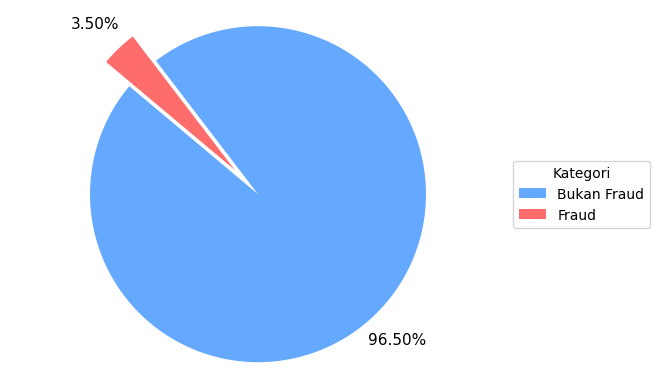

In [5]:
import matplotlib.pyplot as plt

# 1. Hitung jumlah masing-masing kelas
fraud_counts = df_train['isFraud'].value_counts()

labels = ['Bukan Fraud', 'Fraud']
colors = ['#4497ffd2', '#ff4d4dd2']
explode = (0, 0.2)  # Jarak potongan fraud dibuat sedikit lebih renggang

# 2. Plot Pie Chart
wedges, texts, autotexts = plt.pie(
    fraud_counts, 
    explode=explode, 
    colors=colors,
    autopct='%1.2f%%',
    pctdistance=1.2,    # Memindahkan angka persentase ke luar lingkaran (default: 0.6)
    # shadow=True, 
    startangle=140
)

# 3. Perbagus tampilan teks angka di luar
for autotext in autotexts:
    autotext.set_fontsize(11)
    # autotext.set_weight('bold')

# 4. Tambahkan Legend untuk label nama agar tidak menumpuk di luar bersama angka
plt.legend(
    wedges, 
    labels,
    title="Kategori",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1) # Menaruh kotak legend di sebelah kanan luar grafik
)

# plt.title('Proporsi Transaksi: Fraud vs Bukan Fraud', fontsize=14, pad=20)
plt.axis('equal')  
plt.show()

=== MENGHITUNG PERSENTASE MISSING VALUES ===


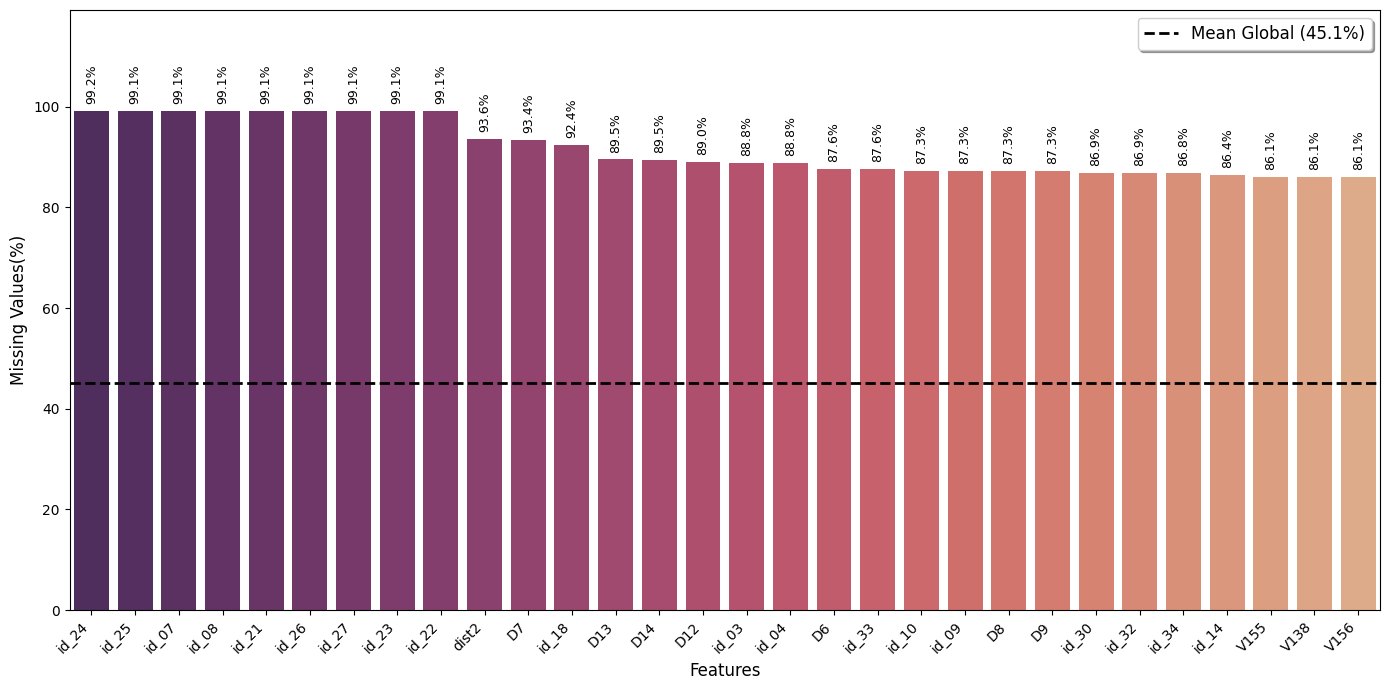

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=== MENGHITUNG PERSENTASE MISSING VALUES ===")

# 1. Hitung total NaN dan persentasenya dari data mentah
missing_counts = df_train.isnull().sum()
missing_percentage = (missing_counts / len(df_train)) * 100

# KUNCI PERBAIKAN: Hitung rata-rata persentase missing values dari SELURUH fitur
avg_missing = missing_percentage.mean()

# 2. Filter dan urutkan
missing_df = pd.DataFrame({
    'Feature': missing_percentage.index,
    'Missing_Pct': missing_percentage.values
})
missing_df = missing_df[missing_df['Missing_Pct'] > 0].sort_values(by='Missing_Pct', ascending=False)

# 3. Ambil Top 30 saja
top_n = 30
missing_plot_data = missing_df.head(top_n)

# 4. Buat Visualisasi Bar Plot
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    x='Feature', 
    y='Missing_Pct', 
    data=missing_plot_data, 
    palette='flare_r' 
)

# 5. TAMBAHAN BARU: Menggambar Garis Rata-rata (Horizontal Line)
plt.axhline(
    y=avg_missing, 
    color='black',            # Warna garis
    linestyle='--',           # Bentuk garis putus-putus
    linewidth=2,              # Ketebalan garis
    label=f'Mean Global ({avg_missing:.1f}%)' # Nama label untuk Legend
)

# 6. Tambahkan teks persentase di atas setiap bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=9, color='black', xytext=(0, 5), 
                textcoords='offset points', rotation=90)

# 7. Pengaturan estetika grafik
# plt.title(f'Top {top_n} Fitur dengan Missing Values Terbanyak', fontsize=16, pad=20)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Missing Values(%)', fontsize=12)

# Miringkan label sumbu X
plt.xticks(rotation=45, ha='right')

# Berikan batas atas sumbu Y sedikit lebih tinggi agar teks tidak terpotong
plt.ylim(0, max(missing_plot_data['Missing_Pct']) + 20)

# Menampilkan Legend (Keterangan) agar garis rata-ratanya bisa dibaca
plt.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

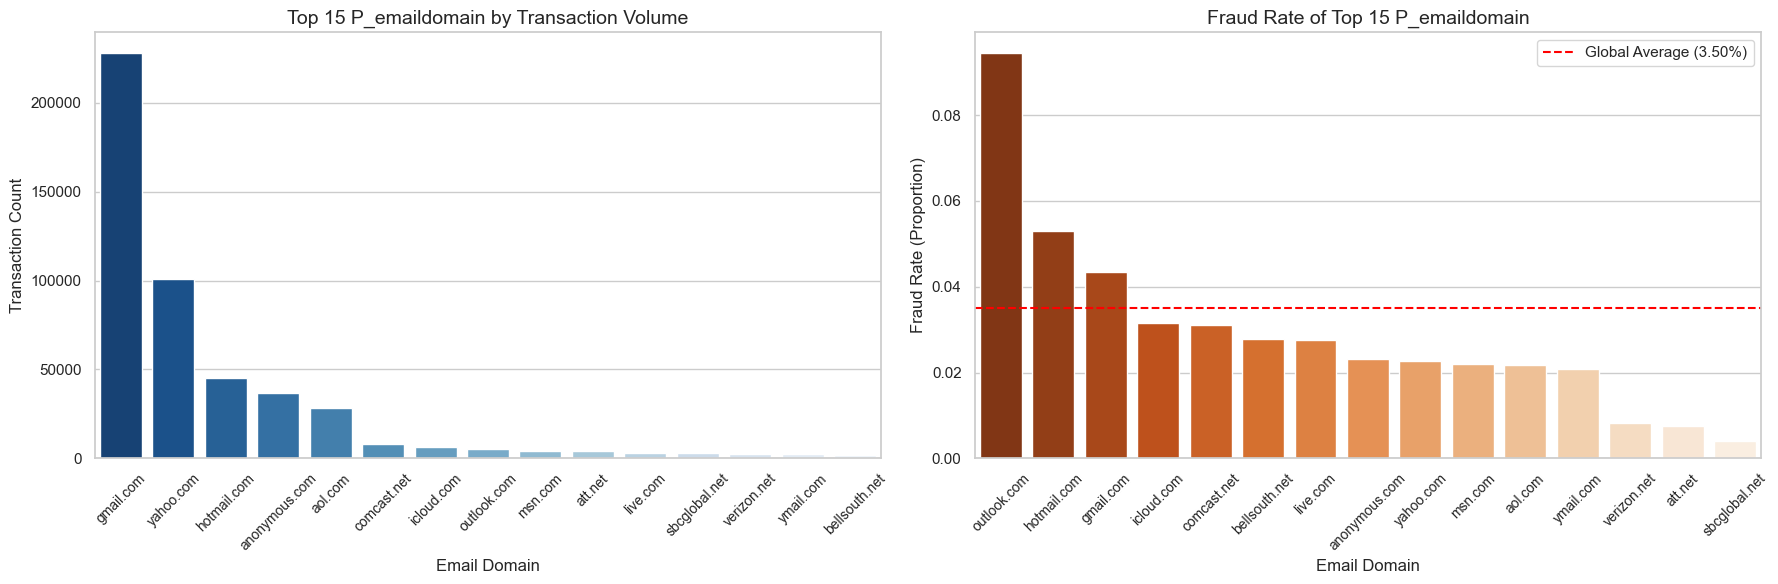

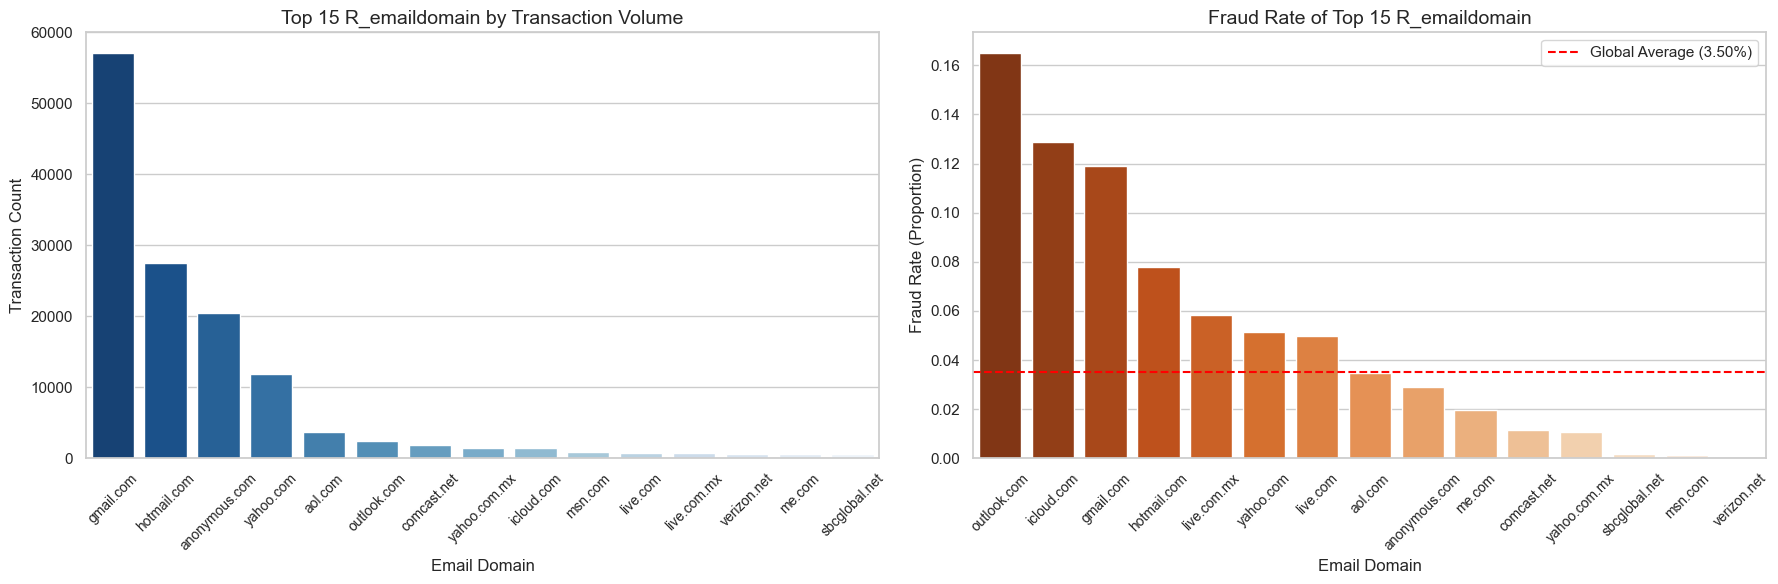

In [6]:
# Set the visualization style
sns.set_theme(style="whitegrid")

def plot_top_email_volume(df, col_name, top_n=15):
    """
    Plots the top N email domains by transaction volume and their respective fraud rates,
    with the fraud rate plot sorted in descending order.
    """
    # 1. Calculate transaction count and fraud rate per email domain
    email_stats = df.groupby(col_name)['isFraud'].agg(['count', 'mean']).reset_index()
    email_stats.columns = [col_name, 'Transaction_Count', 'Fraud_Rate']
    
    # 2. Get Top N domains by transaction volume
    top_volume_emails = email_stats.sort_values(by='Transaction_Count', ascending=False).head(top_n)
    
    # 3. Create a copy sorted by Fraud Rate for the second plot
    top_emails_sorted_by_fraud = top_volume_emails.sort_values(by='Fraud_Rate', ascending=False)
    
    # 4. Initialize the subplots
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # --- LEFT PLOT: Transaction Volume (Sorted by Count) ---
    sns.barplot(
        data=top_volume_emails, 
        x=col_name, 
        y='Transaction_Count', 
        ax=axes[0], 
        palette='Blues_r'
    )
    axes[0].set_title(f'Top {top_n} {col_name} by Transaction Volume', fontsize=14)
    axes[0].set_xlabel('Email Domain', fontsize=12)
    axes[0].set_ylabel('Transaction Count', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45, labelsize=10)
    
    # --- RIGHT PLOT: Fraud Rate (Sorted by Fraud Rate) ---
    sns.barplot(
        data=top_emails_sorted_by_fraud, 
        x=col_name, 
        y='Fraud_Rate', 
        ax=axes[1], 
        palette='Oranges_r'
    )
    # Add global fraud rate benchmark line
    global_fraud_rate = df['isFraud'].mean()
    axes[1].axhline(global_fraud_rate, color='red', linestyle='--', label=f'Global Average ({global_fraud_rate:.2%})')
    
    axes[1].set_title(f'Fraud Rate of Top {top_n} {col_name}', fontsize=14)
    axes[1].set_xlabel('Email Domain', fontsize=12)
    axes[1].set_ylabel('Fraud Rate (Proportion)', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45, labelsize=10)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# Execute for Purchaser Email Domain
plot_top_email_volume(df_train, 'P_emaildomain', top_n=15)

# Execute for Recipient Email Domain
plot_top_email_volume(df_train, 'R_emaildomain', top_n=15)

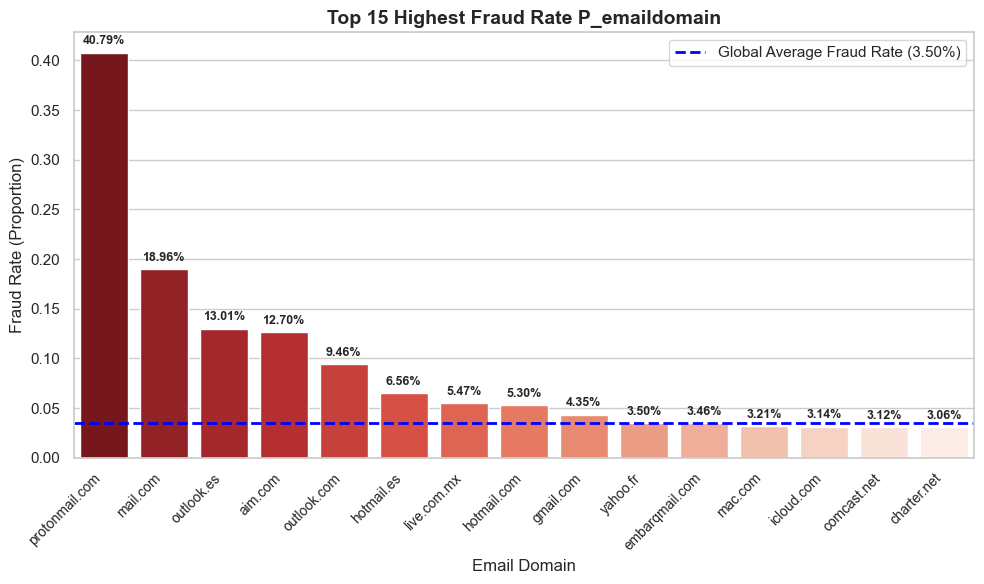

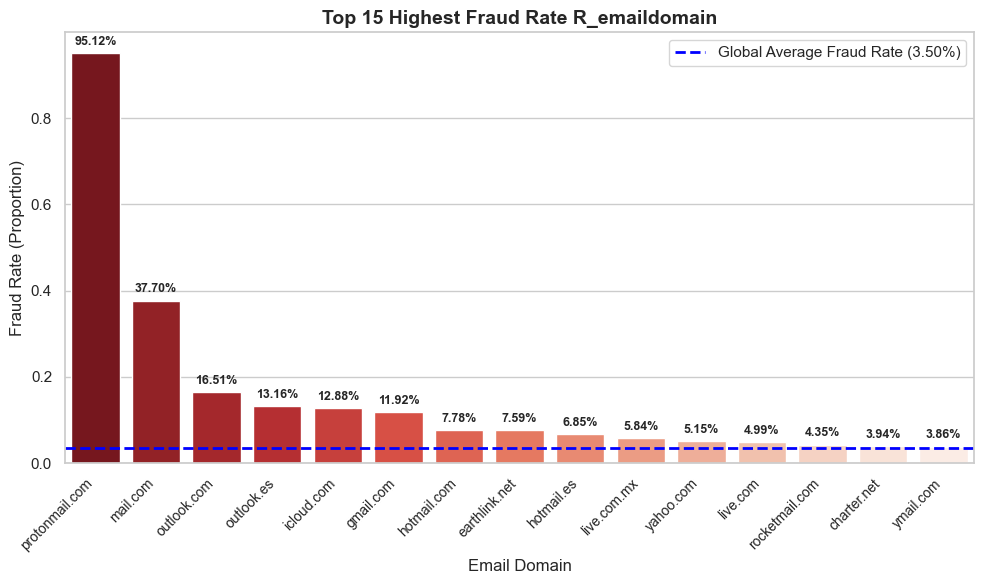

In [15]:
def plot_high_risk_email_domains(df, col_name, min_transactions=30, top_n=15):
    """
    Plots the email domains with the highest fraud rates, filtered by a minimum 
    transaction threshold, and sorted in descending order of fraud rate to match 
    the insights found in the Medium article (e.g., highlighting Protonmail).
    """
    # 1. Calculate transaction count and fraud rate per email domain
    email_stats = df.groupby(col_name)['isFraud'].agg(['count', 'mean']).reset_index()
    email_stats.columns = [col_name, 'Transaction_Count', 'Fraud_Rate']
    
    # 2. Filter out low-volume domains to eliminate statistical noise (e.g., a domain with 1 transaction which happens to be fraud)
    filtered_emails = email_stats[email_stats['Transaction_Count'] >= min_transactions]
    
    # 3. Sort by Fraud Rate in descending order to catch the high-risk domains
    high_risk_emails = filtered_emails.sort_values(by='Fraud_Rate', ascending=False).head(top_n)
    
    # 4. Initialize the plot
    plt.figure(figsize=(10, 6))
    
    # Create the barplot with a high-contrast palette
    sns.barplot(
        data=high_risk_emails,
        x=col_name,
        y='Fraud_Rate',
        palette='Reds_r'
    )
    
    # 5. Add global fraud rate benchmark line
    global_fraud_rate = df['isFraud'].mean()
    plt.axhline(
        global_fraud_rate, 
        color='blue', 
        linestyle='--', 
        linewidth=2,
        label=f'Global Average Fraud Rate ({global_fraud_rate:.2%})'
    )
    
    # 6. Formatting titles and labels
    plt.title(f'Top {top_n} Highest Fraud Rate {col_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Email Domain', fontsize=12)
    plt.ylabel('Fraud Rate (Proportion)', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.legend(fontsize=11)
    
    # Optional: Add data labels on top of each bar for better readability
    for p in plt.gca().patches:
        plt.gca().annotate(
            f"{p.get_height():.2%}", 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', 
            va='center', 
            xytext=(0, 8), 
            textcoords='offset points',
            fontsize=9,
            fontweight='semibold'
        )
        
    plt.tight_layout()
    plt.show()

# Run the function to see the high-risk domains for Purchaser
plot_high_risk_email_domains(df_train, 'P_emaildomain', min_transactions=30, top_n=15)

# Run the function to see the high-risk domains for Recipient
plot_high_risk_email_domains(df_train, 'R_emaildomain', min_transactions=30, top_n=15)

In [4]:
# 1. DEFINE MISSING COLS
# This creates a list of all columns that contain at least one null/NaN value
missing_cols = [col for col in df_train.columns if df_train[col].isnull().any()]

# 2. START OF THE MEDIUM SCRIPT
# We will take all columns and group them based on missing percentage
nan_dict = {}

for col in missing_cols:
    count = df_train[col].isnull().sum()
    try:
        nan_dict[count].append(col)
    except:
        nan_dict[count] = [col]

for k, v in nan_dict.items():
    print(f'#####' * 4)
    print(f'NAN count = {k} percent: {(int(k)/df_train.shape[0])*100:.2f} %')
    print(v)

####################
NAN count = 8933 percent: 1.51 %
['card2']
####################
NAN count = 1565 percent: 0.27 %
['card3']
####################
NAN count = 1577 percent: 0.27 %
['card4']
####################
NAN count = 4259 percent: 0.72 %
['card5']
####################
NAN count = 1571 percent: 0.27 %
['card6']
####################
NAN count = 65706 percent: 11.13 %
['addr1', 'addr2']
####################
NAN count = 352271 percent: 59.65 %
['dist1']
####################
NAN count = 552913 percent: 93.63 %
['dist2']
####################
NAN count = 94456 percent: 15.99 %
['P_emaildomain']
####################
NAN count = 453249 percent: 76.75 %
['R_emaildomain']
####################
NAN count = 1269 percent: 0.21 %
['D1', 'V281', 'V282', 'V283', 'V288', 'V289', 'V296', 'V300', 'V301', 'V313', 'V314', 'V315']
####################
NAN count = 280797 percent: 47.55 %
['D2']
####################
NAN count = 262878 percent: 44.51 %
['D3']
####################
NAN count = 168922 perce

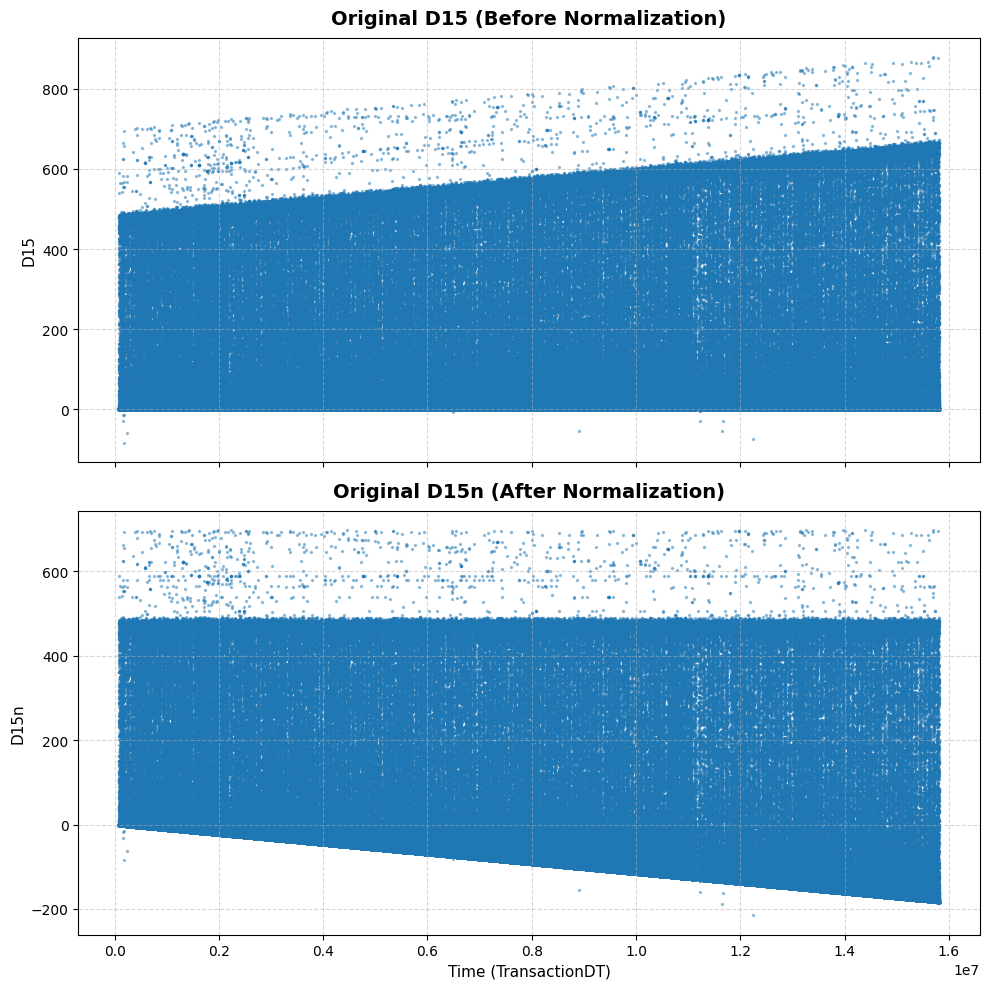

In [19]:
target_col = 'D15'
# ==============================================================================

# 1. Menghitung Fitur Normalisasi Waktu
# Mengubah detik (TransactionDT) menjadi satuan hari
transaction_day = df_train['TransactionDT'] / 86400

# Menghitung nilai D baru (D mentah dikurangi hari berjalan)
df_train[f'{target_col}n'] = df_train[target_col] - transaction_day

# 2. Setup Canvas Visualisasi (Membuat 2 grafik atas-bawah)
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# --- GRAFIK 1: Sebelum Normalisasi (Original) ---
axes[0].scatter(df_train['TransactionDT'], df_train[target_col], s=2, alpha=0.4, color='#1f77b4')
axes[0].set_title(f'Original {target_col} (Before Normalization)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_ylabel(target_col, fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- GRAFIK 2: Sesudah Normalisasi ---
axes[1].scatter(df_train['TransactionDT'], df_train[f'{target_col}n'], s=2, alpha=0.4, color='#1f77b4')
axes[1].set_title(f'Original {target_col}n (After Normalization)', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Time (TransactionDT)', fontsize=11)
axes[1].set_ylabel(f'{target_col}n', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. Merapikan Tata Letak Gambar
plt.tight_layout()

# 4. LANGSUNG TAMPILKAN DI LAPTOP/CELL JUPYTER
plt.show()

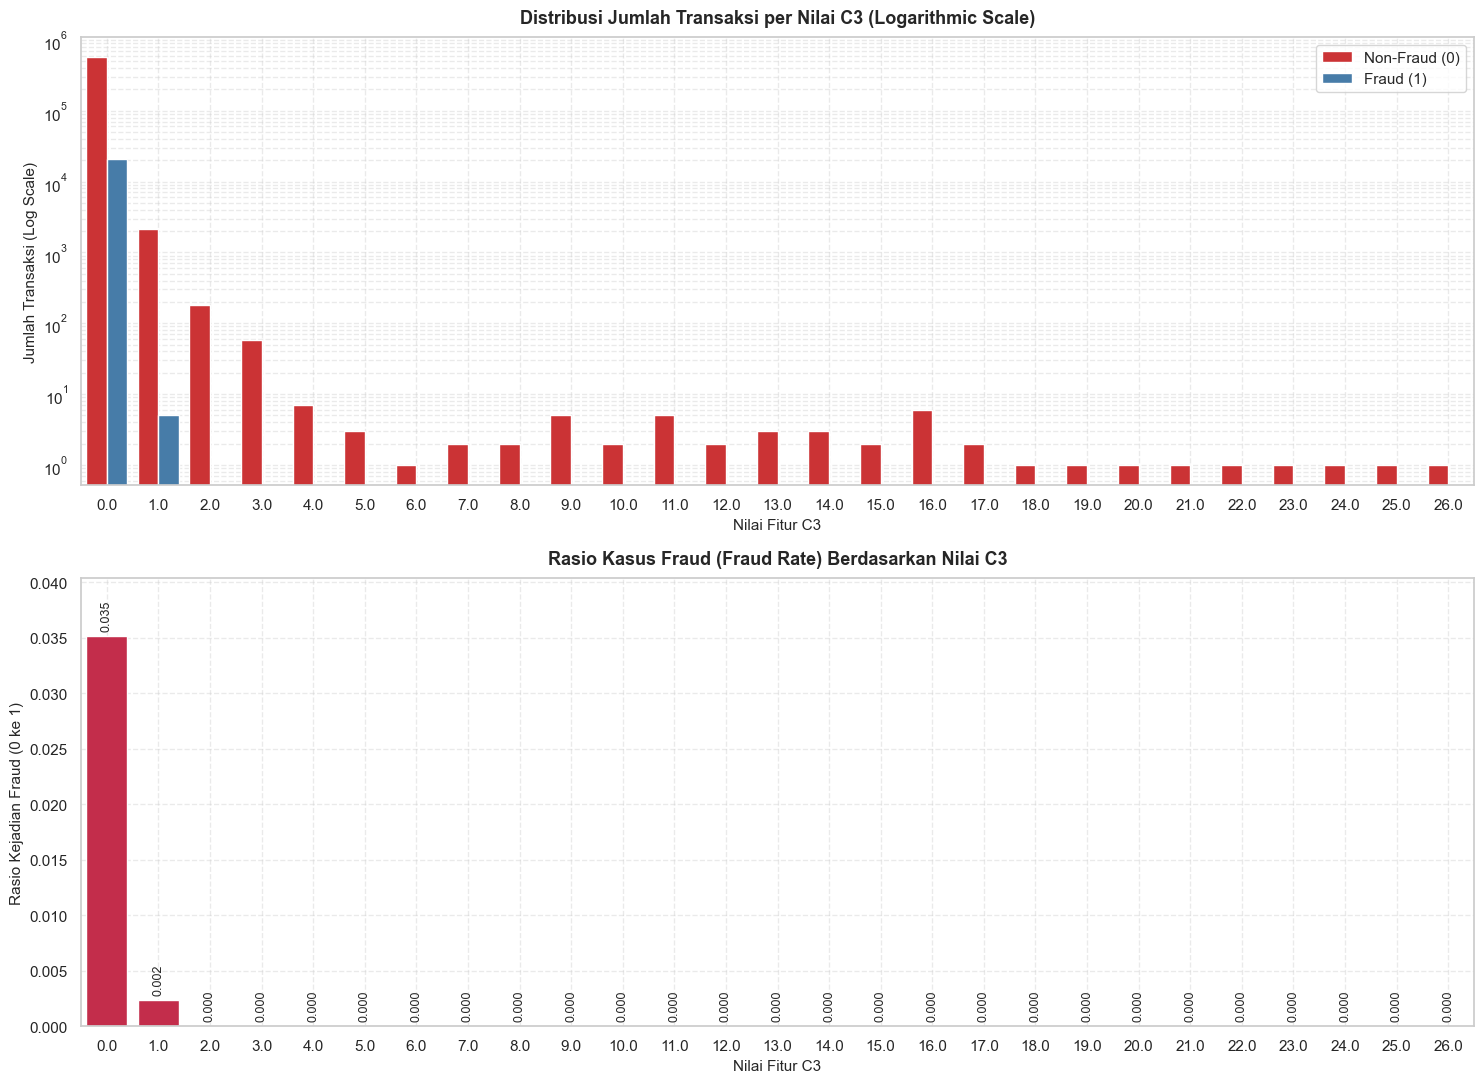

In [7]:
# 1. Menghitung rata-rata fraud (Fraud Rate) untuk setiap nilai C3
c3_fraud_rate = df_train.groupby('C3')['isFraud'].mean().reset_index()

# 2. Setup kanvas menggunakan subplots
fig, axes = plt.subplots(2, 1, figsize=(15, 11), sharex=False)

# ------------------------------------------------------------------------------
# PLOT 1: Jumlah Absolut Transaksi dengan Log Scale
# ------------------------------------------------------------------------------
sns.countplot(
    data=df_train, 
    x='C3', 
    hue='isFraud', 
    ax=axes[0], 
    palette='Set1'
)
axes[0].set_yscale('log')
axes[0].set_title('Distribusi Jumlah Transaksi per Nilai C3 (Logarithmic Scale)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel('Jumlah Transaksi (Log Scale)', fontsize=11)
axes[0].set_xlabel('Nilai Fitur C3', fontsize=11)
axes[0].legend(['Non-Fraud (0)', 'Fraud (1)'], loc='upper right')
axes[0].grid(True, which="both", linestyle='--', alpha=0.4)

# ------------------------------------------------------------------------------
# PLOT 2: Rasio/Persentase Fraud Rate per Nilai C3 + LABEL ANGKA
# ------------------------------------------------------------------------------
barplot_c3 = sns.barplot(
    data=c3_fraud_rate, 
    x='C3', 
    y='isFraud', 
    ax=axes[1], 
    color='crimson'
)

# === BAGIAN BARU: Menambahkan nilai di atas batang ===
# fmt='%.3f' artinya menampilkan 3 angka di belakang koma (contoh: 0.125)
# padding=4 memberikan jarak sedikit antara ujung atas batang dengan teks angka
axes[1].bar_label(
    axes[1].containers[0], 
    fmt='%.3f', 
    padding=4, 
    fontsize=9, 
    rotation=90
)

axes[1].set_title('Rasio Kasus Fraud (Fraud Rate) Berdasarkan Nilai C3', fontsize=13, fontweight='bold', pad=10)
# Menaikkan batas atas sumbu Y sedikit (ditambah 15%) agar teks angka di batang paling tinggi tidak terpotong
axes[1].set_ylim(0, c3_fraud_rate['isFraud'].max() * 1.15) 
axes[1].set_ylabel('Rasio Kejadian Fraud (0 ke 1)', fontsize=11)
axes[1].set_xlabel('Nilai Fitur C3', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.4)

# 3. Merapikan tata letak agar label tidak menumpuk
plt.tight_layout()

# 4. Tampilkan langsung di layar
plt.show()

# Preprocessing

## In Case Error

In [5]:
backup_df_train = df_train.copy()
# df_train = backup_df_train.copy()

## Drop Duplicate

In [6]:
# Tentukan semua kolom kecuali 'TransactionID' sebagai acuan duplikasi
duplicate_cols = df_train.columns.drop('TransactionID')

# Drop duplikat dan reset indeks sekaligus
df_train = df_train.drop_duplicates(subset=duplicate_cols, keep='first').reset_index(drop=True)

## Drop Column

In [7]:
drop_column = ['id_07','id_08','id_21', 'id_22', 'id_23','id_24', 'id_25', 'id_26', 'id_27', 'TransactionID']
df_train.drop(drop_column, axis=1, inplace=True)

## Remove Some V Features

In [8]:
# ==============================================================================
# TAHAP 1 & 2: DEFINE FUNGSI REDUKSI (MENCARI NUNIQUE TERBANYAK)
# ==============================================================================
def reduce_groups(grps, df):
    '''
    Menentukan kolom yang memiliki nilai unik terbanyak di dalam kelompoknya
    '''
    use = []
    for col in grps:
        max_unique = 0
        max_index = 0
        for i, c in enumerate(col):
            n = df[c].nunique()
            if n > max_unique:
                max_unique = n
                max_index = i
        use.append(col[max_index])
    return use

print("=== MEMULAI PROSES REDUKSI FITUR V ===")
print(f"Ukuran df_train awal: {df_train.shape}")

# ==============================================================================
# TAHAP 1: EDA - MENGELOMPOKKAN FITUR V BERDASARKAN JUMLAH NAN
# ==============================================================================
# 1. Ambil semua fitur yang berawalan 'V' dan memiliki nilai NaN
v_missing_cols = [col for col in df_train.columns if col.startswith('V') and df_train[col].isnull().any()]

# 2. Buat dictionary untuk mengelompokkan kolom berdasarkan jumlah NaN yang sama persis
v_nan_dict = {}
for col in v_missing_cols:
    count = df_train[col].isnull().sum()
    try:
        v_nan_dict[count].append(col)
    except:
        v_nan_dict[count] = [col]

# 3. Filter kelompok yang memiliki anggota lebih dari 1 (artinya ada duplikasi/redundansi)
v_groups_to_reduce = [v for k, v in v_nan_dict.items() if len(v) > 1]

# Perhitungan statistik untuk laporan awal
all_v_in_groups = [col for group in v_groups_to_reduce for col in group]
print(f"-> Terdeteksi {len(v_groups_to_reduce)} kelompok fitur V yang saling duplikat secara pola NaN.")
print(f"-> Total fitur V yang masuk dalam radar pemangkasan: {len(all_v_in_groups)} kolom.")

# ==============================================================================
# TAHAP 2: PREPROCESSING - SELEKSI DAN ELIMINASI KOLOM REDUNDAN
# ==============================================================================
# 1. Jalankan fungsi untuk memilih 1 perwakilan terbaik (nunique tertinggi) dari setiap kelompok
v_cols_to_keep = reduce_groups(v_groups_to_reduce, df_train)

# 2. Tentukan daftar kolom yang kalah saing dan harus dibuang
v_cols_to_drop = list(set(all_v_in_groups) - set(v_cols_to_keep))

print(f"-> Jumlah fitur V yang berhasil diselamatkan (dipertahankan): {len(v_cols_to_keep)} kolom.")
print(f"-> Jumlah fitur V redundan yang dieksekusi (dihapus)      : {len(v_cols_to_drop)} kolom.")
print("-" * 65)

# 3. Eksekusi penghapusan kolom dari df_train secara permanen (inplace=True)
df_train.drop(v_cols_to_drop, axis=1, inplace=True)

# ==============================================================================
# HASIL AKHIR
# ==============================================================================
print("✅ TAHAP 2 SELESAI: Fitur V berhasil dirampingkan!")
print(f"Ukuran df_train saat ini: {df_train.shape}")

=== MEMULAI PROSES REDUKSI FITUR V ===
Ukuran df_train awal: (590537, 424)
-> Terdeteksi 15 kelompok fitur V yang saling duplikat secara pola NaN.
-> Total fitur V yang masuk dalam radar pemangkasan: 339 kolom.
-> Jumlah fitur V yang berhasil diselamatkan (dipertahankan): 15 kolom.
-> Jumlah fitur V redundan yang dieksekusi (dihapus)      : 324 kolom.
-----------------------------------------------------------------
✅ TAHAP 2 SELESAI: Fitur V berhasil dirampingkan!
Ukuran df_train saat ini: (590537, 100)


## Normalize D Features

In [9]:
# Menghitung hari berjalannya transaksi (TransactionDT dibagi jumlah detik dalam sehari)
df_train['Transaction_Day'] = df_train['TransactionDT'] / 86400

# Lakukan transformasi untuk semua fitur D (D1 sampai D15)
for i in range(1, 16):
    col = f'D{i}'
    if col in df_train.columns:
        # Rumus yang membuat grafik bergeser rapi menjadi simetris/paralel miring ke bawah
        df_train[f'{col}_norm'] = df_train[col] - df_train['Transaction_Day']
        
        # Drop fitur D asli yang belum dinormalisasi agar tidak membingungkan model
        df_train.drop(col, axis=1, inplace=True)

# Mengisi sisa NaN pada fitur D yang sudah dinormalisasi
for i in range(1, 16):
    norm_col = f'D{i}_norm'
    if norm_col in df_train.columns:
        df_train[norm_col] = df_train[norm_col].fillna(-999)

df_train.drop('Transaction_Day', axis=1, inplace=True)

## Remove Outlier

In [ ]:
# based TransactionAmt
df_train = df_train.drop(df_train[df_train['TransactionAmt'] > 30000].index).reset_index(drop=True)

## Add Time-Related Features

In [ ]:
df_train['Hour'] = (df_train['TransactionDT'] // 3600) % 24
df_train['DayOfWeek'] = (df_train['TransactionDT'] // 86400) % 7

def assign_hour_risk(hour):
    if hour in [2, 3, 4, 5]:
        return 'high'
    elif hour in [0, 1, 6, 23]:
        return 'medium'
    elif hour in [7, 8, 9, 10, 11, 12]:
        return 'low'
    else:
        return 'very_low'

df_train['hour_fraud_status'] = df_train['Hour'].apply(assign_hour_risk)
df_train.drop('TransactionDT', axis=1, inplace=True)

## Create UID

In [13]:
# Membuat ID Pengguna unik berbasis kombinasi kartu dan alamat
df_train['uid'] = df_train['card1'].astype(str) + '_' + df_train['card2'].astype(str) + '_' + df_train['addr1'].astype(str)

# Menghitung total kemunculan ID
uid_counts = df_train['uid'].value_counts()
df_train['uid_count'] = df_train['uid'].map(uid_counts)


## Device Info

In [14]:
if 'DeviceInfo' in df_train.columns:
    df_train['DeviceInfo'] = df_train['DeviceInfo'].fillna('unknown_device').str.lower()
    
    # Fungsi pencocokan string sederhana untuk mengekstrak brand utama perangkat
    def get_device_corp(device_string):
        if 'samsung' in device_string or 'sm-' in device_string:
            return 'samsung'
        elif 'iphone' in device_string or 'ipad' in device_string or 'macos' in device_string or 'apple' in device_string:
            return 'apple'
        elif 'huawei' in device_string or 'ale-' in device_string:
            return 'huawei'
        elif 'lg' in device_string or 'nexus' in device_string:
            return 'lg'
        elif 'windows' in device_string or 'trident' in device_string:
            return 'microsoft'
        elif 'unknown_device' in device_string:
            return 'unknown'
        else:
            return 'other_brands'

    df_train['Device_corp'] = df_train['DeviceInfo'].apply(get_device_corp)
    df_train.drop('DeviceInfo', axis=1, inplace=True)
    print("Device info deleted")

Device info deleted


## TransactionAmt

In [15]:
# Mengambil sisa bagi (desimal) dari nilai transaksi
df_train['cent'] = df_train['TransactionAmt'] - np.floor(df_train['TransactionAmt'])

# Melakukan transformasi Log1p (log(x+1)) untuk menghindari error jika ada nilai 0
df_train['LogTransactionAmt'] = np.log1p(df_train['TransactionAmt'])

## Email

In [16]:
# ------------------------------------------------------------------------------
# 3. PENYEDERHANAAN DOMAIN EMAIL (P_email_company)
# ------------------------------------------------------------------------------
if 'P_emaildomain' in df_train.columns:
    # Mengisi nilai kosong dengan string agar tidak error saat splitting string
    df_train['P_emaildomain'] = df_train['P_emaildomain'].fillna('null')
    
    # Mengambil kata pertama sebelum tanda titik pertama (contoh: 'gmail.com' -> 'gmail')
    df_train['P_email_company'] = df_train['P_emaildomain'].apply(lambda x: x.split('.')[0])

## Aggregation Transaction

In [17]:
# 1. Hitung rata-rata dan standar deviasi nominal transaksi untuk setiap UID
uid_amt_mean = df_train.groupby('uid')['TransactionAmt'].mean()
uid_amt_std = df_train.groupby('uid')['TransactionAmt'].std()

# 2. Petakan (map) hasilnya kembali ke dataframe utama sebagai kolom baru
df_train['uid_amt_mean'] = df_train['uid'].map(uid_amt_mean)
df_train['uid_amt_std'] = df_train['uid'].map(uid_amt_std)

# Isi nilai NaN pada standar deviasi dengan 0 (jika pengguna baru bertransaksi 1 kali)
df_train['uid_amt_std'] = df_train['uid_amt_std'].fillna(0)

# Drop uid
df_train.drop('uid', axis=1, inplace=True)

## Encode and Missing Values (Dari Sebelumnya)

In [ ]:
# #ubah missing values
categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns
# print(categorical_cols)
for col in categorical_cols:
    df_train[col] = df_train[col].fillna('null')

for col in df_train.select_dtypes(include=np.number).columns:
    df_train[col] = df_train[col].fillna(-999)

#ubah ke numerik
encoders = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    df_train[col] = df_train[col].fillna('null').astype(str)
    encoder.fit(df_train[col].unique())
    # encoder.fit(pd.concat([train[col], test[col]], axis=0).unique())

    df_train[col] = encoder.transform(df_train[col])

    if df_train[col].max() > 32000:
        df_train[col] = df_train[col].astype('int32')
    else:
        df_train[col] = df_train[col].astype('int16')
    encoders[col] = encoder

#persiapan split data
x = df_train.drop('isFraud', axis=1)
y = df_train['isFraud']


# Split data
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    x.astype(np.float32), y, 
    test_size=0.20,       # 20% untuk gabungan validation & test
    random_state=42, 
    stratify=y
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, 
    test_size=0.50,       # Membagi 20% menjadi dua bagian (10% & 10%)
    random_state=42, 
    stratify=y_temp       
)

# Normalisasi
scaler = StandardScaler()

# FIT dan TRANSFORM hanya pada data TRAIN
X_train_scaled = scaler.fit_transform(X_train_raw)
X_train = pd.DataFrame(X_train_scaled, columns=x.columns, index=X_train_raw.index)

# HANYA TRANSFORM pada data VALIDATION dan TEST (Menggunakan mean & std dari Train)
X_val_scaled = scaler.transform(X_val_raw)
X_val = pd.DataFrame(X_val_scaled, columns=x.columns, index=X_val_raw.index)

X_test_scaled = scaler.transform(X_test_raw)
X_test = pd.DataFrame(X_test_scaled, columns=x.columns, index=X_test_raw.index)

print(f"Origin Data shape: {backup_df_train.shape}")
print(f"Train shape      : {X_train.shape} ({(X_train.shape[0]/X_train_scaled.shape[0])*100:.0f}%)")
print(f"Validation shape : {X_val.shape} ({(X_val.shape[0]/X_val_scaled.shape[0])*100:.0f}%)")
print(f"Test shape       : {X_test.shape} ({(X_test.shape[0]/X_test_scaled.shape[0])*100:.0f}%)")


Origin Data shape: (590540, 434)
Train shape      : (472428, 107) (80%)
Validation shape : (59053, 107) (10%)
Test shape       : (59054, 107) (10%)


# Feature Store (?)

In [ ]:
import joblib
# Jalankan ini DI AKHIR proses training Anda
inference_artifacts = {
    'v_cols_to_drop': v_cols_to_drop,          # List fitur V yang dibuang
    'uid_counts': uid_counts,                  # Series frequency ID
    'uid_amt_mean': uid_amt_mean,              # Series rata-rata transaksi
    'uid_amt_std': uid_amt_std,                # Series standar deviasi
    'encoders': encoders,                      # Dictionary LabelEncoders
    'scaler': scaler,                          # Fitted StandardScaler (di-fit HANYA dari X_train_raw)
    'training_columns': X_train_raw.columns    # Train columns
}

joblib.dump(inference_artifacts, './model/aiprod_preprocessing.pkl')

['./model/aiprod_preprocessing.pkl']

# Model

## Default

In [12]:
print("LightGBM (Default)	AUC:0.932952	Recall:0.438529	    Precision:0.890855	")

LightGBM (Default)	AUC:0.932952	Recall:0.438529	    Precision:0.890855	


In [ ]:

# Jalankan training asli Anda
# lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model = lgb.LGBMClassifier(
    learning_rate=0.01,
    max_depth=12,
    n_estimators=10000,
    subsample=0.8,        
    colsample_bytree=0.4,
    boosting_type= 'gbdt',
    random_state=42,
    force_row_wise=True
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

# === TAMBAHKAN INI DI BAWAHNYA ===
from sklearn.metrics import classification_report, roc_auc_score

# Ambil nilai probabilitas mentah untuk kelas fraud (kelas 1)
y_prob = lgb_model.predict_proba(X_val)[:, 1]

# Ambil prediksi label biner berdasarkan threshold default (0.5)
y_pred = (y_prob >= 0.5).astype(int)

# Hitung ketiga metrik evaluasi
auc_val = roc_auc_score(y_val, y_prob)
recall_val = recall_score(y_val, y_pred, pos_label=1)
precision_val = precision_score(y_val, y_pred, pos_label=1, zero_division=0)

# Cetak hasil satu baris sesuai format yang Anda inginkan
print("\n" + "="*70)
print(f"\nLightGBM (Default)   AUC:{auc_val:.6f}    Recall:{recall_val:.6f}     Precision:{precision_val:.6f}")

[LightGBM] [Info] Number of positive: 16530, number of negative: 455898
[LightGBM] [Info] Total Bins 14045
[LightGBM] [Info] Number of data points in the train set: 472428, number of used features: 107
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317092
[LightGBM] [Info] Start training from score -3.317092
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.88676	valid_0's binary_logloss: 0.105571
[200]	valid_0's auc: 0.897833	valid_0's binary_logloss: 0.0949805
[300]	valid_0's auc: 0.907459	valid_0's binary_logloss: 0.0895456
[400]	valid_0's auc: 0.914478	valid_0's binary_logloss: 0.0859367
[500]	valid_0's auc: 0.92075	valid_0's binary_logloss: 0.083204
[600]	valid_0's auc: 0.926318	valid_0's binary_logloss: 0.0809582
[700]	valid_0's auc: 0.930456	valid_0's binary_logloss: 0.0790129
[800]	valid_0's auc: 0.933686	valid_0's binary_logloss: 0.0774713
[900]	valid_0's auc: 0.936171	valid_0's binary_logloss: 0.0761428
[1000]	valid

## Save Model

In [21]:
joblib.dump(lgb_model, './model/aiprod_lightgbm_best.pkl')

['./model/aiprod_lightgbm_best.pkl']

# Evaluasi

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8

ROC AUC Score di Data Validation: 0.9688


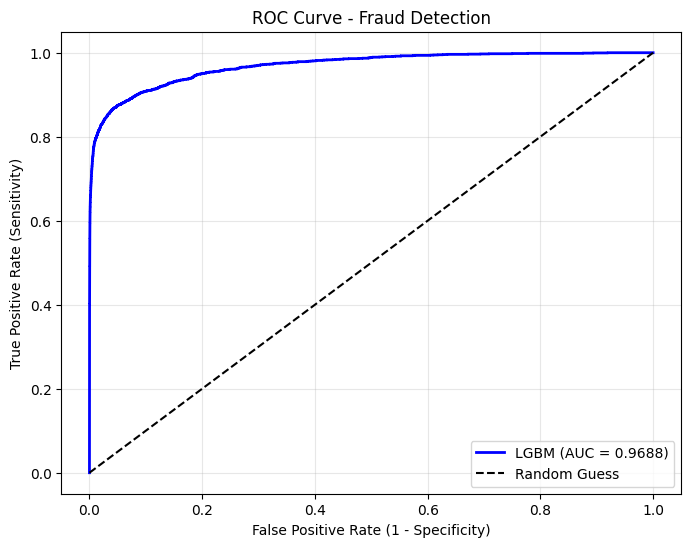

### Classification Report ###
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     56987
           1       0.96      0.60      0.74      2066

    accuracy                           0.99     59053
   macro avg       0.97      0.80      0.86     59053
weighted avg       0.98      0.99      0.98     59053



<Figure size 800x600 with 0 Axes>

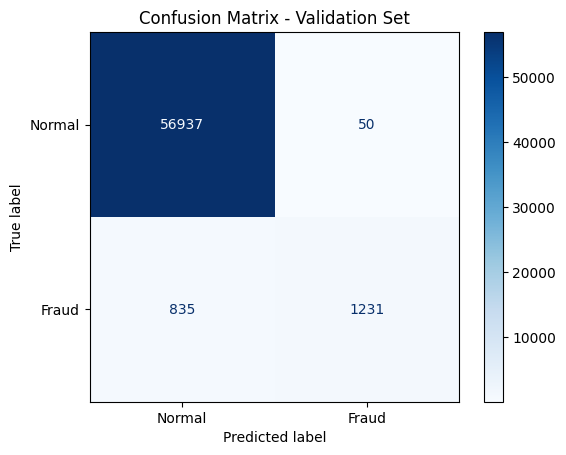

In [19]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_proba = lgb_model.predict_proba(X_val)[:, 1]

# 2. Hitung Skor AUC
auc_score = roc_auc_score(y_val, y_pred_proba)
print(f"\nROC AUC Score di Data Validation: {auc_score:.4f}")

# 3. Plot Kurva ROC
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LGBM (AUC = {auc_score:.4f})', color='blue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Fraud Detection')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


# 1. Ubah probabilitas menjadi label (0 atau 1)
# Threshold default adalah 0.5
y_pred_label = (y_pred_proba > 0.5).astype(int)

# 2. Cetak Classification Report
print("### Classification Report ###")
print(classification_report(y_val, y_pred_label))

# 3. Buat Confusion Matrix
cm = confusion_matrix(y_val, y_pred_label)

# 4. Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Validation Set')
plt.show()

## SHAP

c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


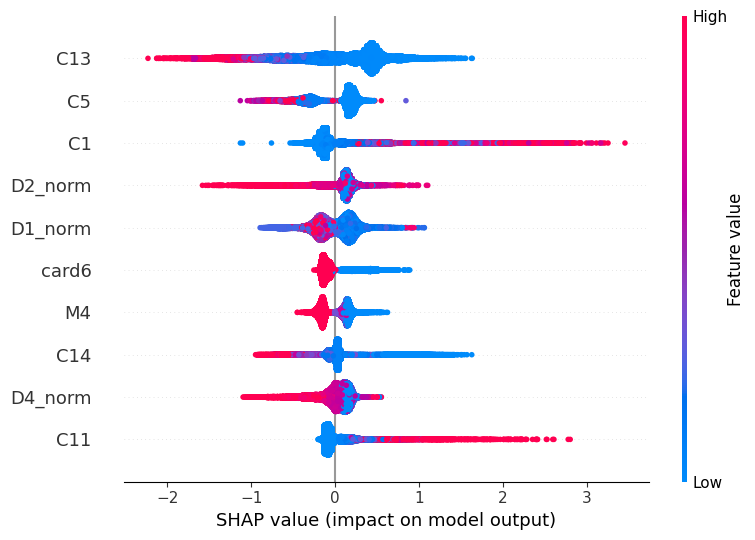

In [24]:
import shap

# 1. Buat Tree Explainer khusus untuk LightGBM
explainer = shap.TreeExplainer(lgb_model)

# 2. Hitung SHAP values menggunakan data validasi (X_val)
# Tips: Jika data terlalu besar dan prosesnya lama, batasi barisnya, misal: X_val.iloc[:2000]
shap_values = explainer.shap_values(X_val)

# 3. Tampilkan 10 fitur terpenting (max_display=10)
# Pada binary classification, shap_values biasanya berupa list untuk [class 0, class 1].
# Kita ambil indeks 1 karena fokus pada kelas 1 (isFraud).
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_val, max_display=10)
else:
    shap.summary_plot(shap_values, X_val, max_display=10)

In [35]:
import numpy as np
import pandas as pd
import shap

# 1. Hitung SHAP dan ambil 10 fitur teratas
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_val)
shap_matrix = shap_values[1] if isinstance(shap_values, list) else shap_values

mean_abs_shap = np.abs(shap_matrix).mean(axis=0)
top_10_features = pd.DataFrame({
    'Feature Name': X_val.columns,
    'SHAP': mean_abs_shap
}).sort_values(by='SHAP', ascending=False).head(10)['Feature Name'].tolist()

# 2. Ekstrak profil fitur dari backup_df_train berdasarkan top 10 fitur tersebut
profile_results = []
total_rows = len(backup_df_train)

for col in top_10_features:
    original_col = col
    if col.endswith('_norm') and col.replace('_norm', '') in backup_df_train.columns:
        original_col = col.replace('_norm', '')
    elif col == 'Device_corp' and 'DeviceInfo' in backup_df_train.columns:
        original_col = 'DeviceInfo'
    elif col in ['Hour', 'DayOfWeek', 'hour_fraud_status', 'cent', 'LogTransactionAmt', 'uid_count', 'uid_amt_mean', 'uid_amt_std']:
        original_col = col
        
    target_df = backup_df_train if original_col in backup_df_train.columns else x_scaled
    
    # KUNCI PERBAIKAN: Memisahkan pembentukan string kategori agar tidak bentrok kutip ganda
    if target_df[original_col].dtype in ['object', 'category']:
        data_type = 'Categorical'
        unique_vals = [str(x) for x in target_df[original_col].dropna().unique()[:3]]
        formatted_vals = ", ".join([f"'{v}'" for v in unique_vals])
        val_range = f"[{formatted_vals}]..."
    else:
        data_type = 'Continuous/Numerical'
        v_min = target_df[original_col].min()
        v_max = target_df[original_col].max()
        val_range = f"{v_min:.1f} - {v_max:.1f}" if not pd.isna(v_min) else "N/A"
        
    # Hitung Missing Values
    null_count = target_df[original_col].isnull().sum()
    null_pct = (null_count / len(target_df)) * 100
    missing_str = f"{null_count} ({null_pct:.2f}%)"
    
    profile_results.append({
        'Feature Name': col,
        'Data Type': data_type,
        'Value Range / Categories': val_range,
        'Missing Values': missing_str
    })

# 3. Konversi ke DataFrame laporan
df_profile_report = pd.DataFrame(profile_results)

# 4. Tampilkan Laporan Ke Layar
print("="*48, "10 MOST IMPORTANT FEATURES PROFILE", "="*48)
df_profile_report

================================================ 10 MOST IMPORTANT FEATURES PROFILE ================================================


c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,Feature Name,Data Type,Value Range / Categories,Missing Values
0,C13,Continuous/Numerical,0.0 - 2918.0,0 (0.00%)
1,C5,Continuous/Numerical,0.0 - 349.0,0 (0.00%)
2,C1,Continuous/Numerical,0.0 - 4685.0,0 (0.00%)
3,D2_norm,Continuous/Numerical,0.0 - 640.0,280797 (47.55%)
4,D1_norm,Continuous/Numerical,0.0 - 640.0,1269 (0.21%)
5,card6,Categorical,"['credit', 'debit', 'debit or credit']...",1571 (0.27%)
6,M4,Categorical,"['M2', 'M0', 'M1']...",281444 (47.66%)
7,C14,Continuous/Numerical,0.0 - 1429.0,0 (0.00%)
8,D4_norm,Continuous/Numerical,-122.0 - 869.0,168922 (28.60%)
9,C11,Continuous/Numerical,0.0 - 3188.0,0 (0.00%)


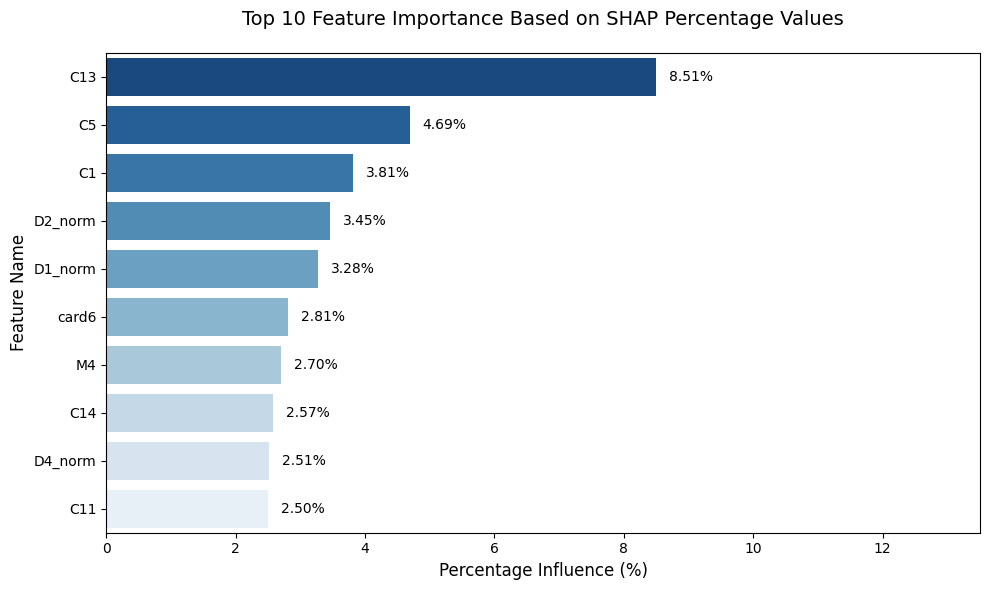

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Hitung total SHAP dari semua fitur untuk mencari persentase
total_shap_importance = np.sum(mean_abs_shap)
shap_percentages = (mean_abs_shap / total_shap_importance) * 100

# 2. Buat DataFrame khusus plot dan ambil Top 10
df_shap_plot = pd.DataFrame({
    'Feature Name': X_val.columns,
    'SHAP Percentage': shap_percentages
}).sort_values(by='SHAP Percentage', ascending=False).head(10)

# 3. Pengaturan ukuran kanvas grafik
plt.figure(figsize=(10, 6))

# 4. Buat Barplot menggunakan Seaborn untuk mendapatkan gradasi warna 'Blues_r' (Reverse Blues)
ax = sns.barplot(
    x='SHAP Percentage', 
    y='Feature Name', 
    data=df_shap_plot, 
    palette='Blues_r'
)

# 5. Tambahkan teks persentase di ujung setiap bar
for p in ax.patches:
    width = p.get_width()
    # Menambahkan teks dengan sedikit jarak (0.2) dari ujung bar
    plt.text(
        width + 0.2, 
        p.get_y() + p.get_height() / 2, 
        f'{width:.2f}%', 
        ha="left", 
        va="center", 
        fontsize=10, 
        color='black'
    )

# 6. Pengaturan Label, Judul, dan Batas Sumbu X
plt.title('Top 10 Feature Importance Based on SHAP Percentage Values', fontsize=14, pad=20)
plt.xlabel('Percentage Influence (%)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

# Perlebar sedikit sumbu X agar teks persentase tidak terpotong tepi kanan grafik
plt.xlim(0, df_shap_plot['SHAP Percentage'].max() + 5)

# 7. Tampilkan grafik dengan tata letak yang rapi
plt.tight_layout()
plt.show()

# Compare Models

In [ ]:
# 1. Define all the models termasuk perbaikan warning LightGBM & penambahan force_row_wise
models = {
    'XGBoost (Default)': xgb.XGBClassifier(random_state=42),
    'XGBoost (Tuned)': xgb.XGBClassifier(
        learning_rate=0.1,  
        max_depth=9,        
        n_estimators=200,   
        random_state=42
    ),
    'LightGBM (Default)': lgb.LGBMClassifier(random_state=42, force_row_wise=True),
    'LightGBM (Tuned)': lgb.LGBMClassifier(
        learning_rate=0.01,  
        max_depth=12,        
        n_estimators=10000,   
        # bagging_fraction=0.8,
        # feature_fraction=0.4,
        subsample=0.8,        
        colsample_bytree=0.4,
        boosting_type='gbdt',
        random_state=42,
        force_row_wise=True # Menghilangkan overhead info log
    ),
    'Logistic Regression (Default)': LogisticRegression(random_state=42),
    'Logistic Regression (Max Iter 10k)': LogisticRegression(max_iter=10000, random_state=42)
}

# 2. Placeholder list to store evaluation results
results_list = []

print("Starting model training and evaluation (6 models total)...\n")

# Hitung jumlah data sampel validasi untuk pembagi waktu inferensi
num_samples = len(X_val)

# 3. Loop through each model, train, and calculate metrics
for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    # Measure training time
    start_train = time.time()
    model.fit(X_train, y_train)
    end_train = time.time()
    
    training_duration = end_train - start_train
    
    # === BAGIAN PENGUKURAN WAKTU INFERENSI ===
    start_inf = time.time()
    y_pred = model.predict(X_val)
    end_inf = time.time()
    
    # Total waktu inferensi untuk seluruh X_val (detik)
    total_inference_time = end_inf - start_inf
    # Rata-rata waktu inferensi per sampel (diubah ke milidetik / ms agar lebih mudah dibaca)
    avg_inference_per_sample_ms = (total_inference_time / num_samples) * 1000
    # =========================================
    
    # Predict probabilities for AUC score
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)[:, 1]
    else:
        y_prob = model.decision_function(X_val)
        
    # Calculate metrics targeting the fraud class (class 1)
    auc = roc_auc_score(y_val, y_prob)
    recall = recall_score(y_val, y_pred, pos_label=1)
    precision = precision_score(y_val, y_pred, pos_label=1, zero_division=0)
    
    # Append metrics to the results list
    results_list.append({
        'Model Name': model_name,
        'AUC Score': auc,
        'Recall (Fraud)': recall,
        'Precision (Fraud)': precision,
        'Training Time (s)': training_duration,
        'Avg Inference (ms)': avg_inference_per_sample_ms  # Metrik Baru
    })

# 4. Convert the results into a unified Pandas DataFrame
df_eval_results = pd.DataFrame(results_list)

# 5. Sort the dataframe by AUC Score for better comparison
df_eval_results = df_eval_results.sort_values(by='AUC Score', ascending=False).reset_index(drop=True)

# Display the evaluation dataframe
print("\n" + "="*70)
print("                    MODEL EVALUATION REPORT                       ")
print("="*70)
df_eval_results

Starting model training and evaluation (6 models total)...

Training XGBoost (Default)...
Training XGBoost (Tuned)...
Training LightGBM (Default)...
[LightGBM] [Info] Number of positive: 16530, number of negative: 455898
[LightGBM] [Info] Total Bins 14045
[LightGBM] [Info] Number of data points in the train set: 472428, number of used features: 107
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317092
[LightGBM] [Info] Start training from score -3.317092
Training LightGBM (Tuned)...
[LightGBM] [Info] Number of positive: 16530, number of negative: 455898
[LightGBM] [Info] Total Bins 14045
[LightGBM] [Info] Number of data points in the train set: 472428, number of used features: 107
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317092
[LightGBM] [Info] Start training from score -3.317092
Training Logistic Regression (Default)...


c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Logistic Regression (Max Iter 10k)...

                    MODEL EVALUATION REPORT                       


,Model Name,AUC Score,Recall (Fraud),Precision (Fraud),Training Time (s),Avg Inference (ms)
0,LightGBM (Tuned),0.974403,0.609874,0.968486,221.058242,0.108728
1,XGBoost (Tuned),0.971030,0.611326,0.949624,12.071538,0.001946
2,XGBoost (Default),0.953148,0.530494,0.911814,3.566839,0.000684
3,LightGBM (Default),0.937983,0.427396,0.879482,3.760635,0.001044
4,Logistic Regression (Max Iter 10k),0.823565,0.083737,0.717842,94.034982,0.000372
5,Logistic Regression (Default),0.820235,0.078896,0.747706,8.295075,0.000325


In [ ]:
from sklearn.metrics import recall_score, precision_score, roc_auc_score, f1_score
# List of thresholds to evaluate
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
threshold_results = []

print("Evaluating and sorting thresholds with AUC and F1 scores for tree-based models...\n")

# Loop through your existing 'models' dictionary
for model_name, model in models.items():
    # Only process tree-based models that support probability predictions
    if hasattr(model, "predict_proba"):
        
        # Get raw probabilities for the fraud class (class 1)
        y_prob = model.predict_proba(X_val)[:, 1]
        
        # Calculate AUC Score (remains constant per model across all thresholds)
        auc = roc_auc_score(y_val, y_prob)
        
        for thresh in thresholds:
            # Convert probabilities to binary labels based on custom threshold
            y_pred_custom = (y_prob >= thresh).astype(int)
            
            # Calculate evaluation metrics
            recall = recall_score(y_val, y_pred_custom, pos_label=1)
            precision = precision_score(y_val, y_pred_custom, pos_label=1, zero_division=0)
            
            # === TAMBAHAN BARU: Menghitung F1-Score ===
            f1 = f1_score(y_val, y_pred_custom, pos_label=1, zero_division=0)
            
            threshold_results.append({
                'Model Name': model_name,
                'Threshold': thresh,
                # 'AUC Score': auc,
                'F1-Score': f1,              # <-- Masukkan ke dictionary
                'Recall (Fraud)': recall,
                'Precision (Fraud)': precision
            })

# Convert to DataFrame
df_threshold_audit = pd.DataFrame(threshold_results)

# === PERUBAHAN SORTING: Urutkan berdasarkan F1-Score ===
# Dengan ini, threshold yang paling seimbang (biasanya 0.2 atau 0.3) akan otomatis naik ke nomor 1
df_threshold_sorted = df_threshold_audit.sort_values(
    by=['F1-Score', 'Recall (Fraud)'], 
    ascending=[False, False]
).reset_index(drop=True)

# Display the sorted dataframe
print("="*100)
print(f"{'THRESHOLD TUNING REPORT (SORTED BY F1-SCORE)':^100}")
print("="*100)
df_threshold_sorted

Evaluating and sorting thresholds with AUC and F1 scores for tree-based models...

                            THRESHOLD TUNING REPORT (SORTED BY F1-SCORE)                            


,Model Name,Threshold,AUC Score,F1-Score,Recall (Fraud),Precision (Fraud)
0,LightGBM (Tuned),0.2,0.974403,0.809487,0.768151,0.855526
1,LightGBM (Tuned),0.3,0.974403,0.801417,0.712004,0.916511
2,XGBoost (Tuned),0.2,0.971030,0.784134,0.746370,0.825924
3,LightGBM (Tuned),0.4,0.974403,0.779265,0.662149,0.946713
4,XGBoost (Tuned),0.3,0.971030,0.776810,0.690707,0.887438
5,XGBoost (Tuned),0.4,0.971030,0.764556,0.651500,0.925086
6,LightGBM (Tuned),0.1,0.974403,0.748809,0.836883,0.677508
7,LightGBM (Tuned),0.5,0.974403,0.748441,0.609874,0.968486
8,XGBoost (Tuned),0.5,0.971030,0.743816,0.611326,0.949624
9,XGBoost (Tuned),0.1,0.971030,0.719115,0.818490,0.641259


# Inference (Testing)

In [22]:
import pandas as pd
import numpy as np

def preprocess_inference(df_input, artifacts):
    """
    Fungsi inference untuk mempersiapkan raw data tunggal menjadi data siap prediksi.
    Mendukung single instance (1 baris) maupun batch dari satu dataframe utuh.
    """
    df = df_input.copy()

    # 1. Pengecekan dan Rename ID (Langsung pada dataframe input)
    wrong_id_cols = [col for col in df.columns if 'id-' in str(col)]
    if len(wrong_id_cols) > 0:
        id_cols = [col for col in df.columns if str(col)[:2] == 'id']
        rename_cols = {i: 'id_' + str(i[-2:]) for i in id_cols if '-' in i}
        df.rename(columns=rename_cols, inplace=True)
        
    # Catat TransactionID (jika ada) untuk dikembalikan di akhir
    transaction_ids = df['TransactionID'].copy() if 'TransactionID' in df.columns else None

    # 2. Drop Kolom Standar dan Kolom V Redundan
    drop_column = ['id_07','id_08','id_21', 'id_22', 'id_23','id_24', 'id_25', 'id_26', 'id_27', 'TransactionID']
    cols_to_drop = [c for c in drop_column + artifacts['v_cols_to_drop'] if c in df.columns]
    df.drop(cols_to_drop, axis=1, inplace=True)

    # 3. Fitur Waktu dan Transformasi D
    if 'TransactionDT' in df.columns:
        df['Transaction_Day'] = df['TransactionDT'] / 86400
        for i in range(1, 16):
            col = f'D{i}'
            if col in df.columns:
                df[f'{col}_norm'] = df[col] - df['Transaction_Day']
                df.drop(col, axis=1, inplace=True)

        # Ekstraksi Jam dan Hari
        df['Hour'] = (df['TransactionDT'] // 3600) % 24
        df['DayOfWeek'] = (df['TransactionDT'] // 86400) % 7
        df.drop(['TransactionDT', 'Transaction_Day'], axis=1, inplace=True)

    for i in range(1, 16):
        norm_col = f'D{i}_norm'
        if norm_col in df.columns:
            df[norm_col] = df[norm_col].fillna(-999)

    # 4. Kategori Jam Rawan
    def assign_hour_risk(hour):
        if hour in [2, 3, 4, 5]: return 'high'
        elif hour in [0, 1, 6, 23]: return 'medium'
        elif hour in [7, 8, 9, 10, 11, 12]: return 'low'
        else: return 'very_low'
    
    if 'Hour' in df.columns:
        df['hour_fraud_status'] = df['Hour'].apply(assign_hour_risk)

    # 5. Ekstraksi DeviceInfo
    if 'DeviceInfo' in df.columns:
        df['DeviceInfo'] = df['DeviceInfo'].fillna('unknown_device').str.lower()
        def get_device_corp(device_string):
            if 'samsung' in device_string or 'sm-' in device_string: return 'samsung'
            elif 'iphone' in device_string or 'ipad' in device_string or 'macos' in device_string or 'apple' in device_string: return 'apple'
            elif 'huawei' in device_string or 'ale-' in device_string: return 'huawei'
            elif 'lg' in device_string or 'nexus' in device_string: return 'lg'
            elif 'windows' in device_string or 'trident' in device_string: return 'microsoft'
            elif 'unknown_device' in device_string: return 'unknown'
            else: return 'other_brands'
        df['Device_corp'] = df['DeviceInfo'].apply(get_device_corp)
        df.drop('DeviceInfo', axis=1, inplace=True)

    # 6. Nominal Transaksi
    if 'TransactionAmt' in df.columns:
        df['cent'] = df['TransactionAmt'] - np.floor(df['TransactionAmt'])
        df['LogTransactionAmt'] = np.log1p(df['TransactionAmt'])

    # 7. UID dan Group Aggregation (Mapping dari artefak)
    if all(c in df.columns for c in ['card1', 'card2', 'addr1']):
        df['uid'] = df['card1'].astype(str) + '_' + df['card2'].astype(str) + '_' + df['addr1'].astype(str)
        df['uid_count'] = df['uid'].map(artifacts['uid_counts']).fillna(1)
        df['uid_amt_mean'] = df['uid'].map(artifacts['uid_amt_mean']).fillna(df['TransactionAmt'] if 'TransactionAmt' in df.columns else 0)
        df['uid_amt_std'] = df['uid'].map(artifacts['uid_amt_std']).fillna(0)
        df.drop('uid', axis=1, inplace=True)

    # 8. Handling Missing Values
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        df[col] = df[col].fillna('null')

    for col in df.select_dtypes(include=np.number).columns:
        df[col] = df[col].fillna(-999)

    # 9. Label Encoding
    for col in categorical_cols:
        if col in artifacts['encoders']:
            encoder = artifacts['encoders'][col]
            df[col] = df[col].astype(str)
            
            # Trik mencegah error untuk kategori yang belum pernah dilihat saat training
            known_classes = set(encoder.classes_)
            df[col] = df[col].apply(lambda x: x if x in known_classes else 'null')
            
            df[col] = encoder.transform(df[col])
            df[col] = df[col].astype('int32')

    # 10. Penyelarasan Kolom & Scaling
    # Pastikan hanya mengambil kolom yang ada di model training, dan urutannya persis
    df = df.reindex(columns=artifacts['training_columns'], fill_value=-999)
    
    df_scaled = artifacts['scaler'].transform(df.astype(np.float32))
    df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

    return df_scaled, transaction_ids

# Test Submit Kaggle

In [ ]:
print("=== MEMULAI PROSES INFERENCE DATA TEST ===")

# 1. Baca data mentah
test_transaction = pd.read_csv('./dataset/test_transaction.csv')
test_identity = pd.read_csv('./dataset/test_identity.csv')

# 2. Gabungkan data persis seperti alur di tahap training
df_test_raw = test_transaction.merge(test_identity, on=['TransactionID'], how='left')
print(f"Data test berhasil digabung. Ukuran awal: {df_test_raw.shape}")

# 3. Muat artefak preprocessing yang sudah disimpan sebelumnya
# (Pastikan file .pkl berada di direktori yang sama atau sesuaikan path-nya)
loaded_artifacts = joblib.load('./model/aiprod_preprocessing.pkl')

# 4. Jalankan fungsi inference
X_inference, inference_ids = preprocess_inference(df_test_raw, loaded_artifacts)

print("=== MENYIAPKAN FILE SUBMISSION KAGGLE ===")

# 1. Gunakan predict_proba, BUKAN predict!
# Ambil kolom indeks 1 (probabilitas transaksi tersebut adalah Fraud)
isFraud_prob = lgb_model.predict_proba(X_inference)[:, 1]

# 2. Buat DataFrame menggunakan inference_ids yang sudah diekstrak oleh fungsi preprocessing kita
test_result = pd.DataFrame({
    'TransactionID': inference_ids, 
    'isFraud': isFraud_prob
})

# 3. Simpan ke CSV sesuai dengan nama file yang Anda inginkan
file_name = '2026 05 20 submission.csv'
test_result.to_csv(file_name, index=False)

print(f"✅ File '{file_name}' berhasil dibuat!")

=== MEMULAI PROSES INFERENCE DATA TEST ===
Data test berhasil digabung. Ukuran awal: (506691, 433)
=== MENYIAPKAN FILE SUBMISSION KAGGLE ===
✅ File '2026 05 20 submission.csv' berhasil dibuat!


# Racism Test (Fairlearn)

In [38]:
import pandas as pd
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate
from sklearn.metrics import f1_score

print("=== EVALUASI FAIRNESS MODEL MENGGUNAKAN FAIRLEARN ===")

# 1. Tentukan fitur sensitif yang ingin dievaluasi (pastikan fitur ini ada di data validasi)
# Karena Device_corp sebelumnya sudah di-encode ke angka, pastikan Anda menggunakan versi aslinya 
# atau mapping balik ke teks agar laporannya mudah dibaca.
sensitive_feature = df_train.loc[X_val.index, 'Device_corp'] # Mengambil label asli dari backup

# 2. Gunakan probabilitas model dan aplikasikan threshold terbaik Anda (misal: 0.2)
threshold = 0.2
y_pred_prob = lgb_model.predict_proba(X_val)[:, 1]
y_pred_custom = (y_pred_prob >= threshold).astype(int)

# 3. Definisikan metrik yang ingin dilihat perbatasannya
metrics_dict = {
    'Selection Rate (Total Diblokir)': selection_rate,
    'Recall (TPR - Fraud Tertangkap)': true_positive_rate,
    'FPR (False Alarm - Normal Diblokir)': false_positive_rate
}

# 4. Masukkan ke dalam MetricFrame Fairlearn
metric_frame = MetricFrame(
    metrics=metrics_dict,
    y_true=y_val,
    y_pred=y_pred_custom,
    sensitive_features=sensitive_feature
)

# 5. Tampilkan metrik secara keseluruhan (Overall)
print("\n--- OVERALL METRICS ---")
print(metric_frame.overall)

# 6. Tampilkan metrik berdasarkan kelompok (By Group)
print("\n--- METRICS BY GROUP (DEVICE CORP) ---")
display(metric_frame.by_group) # Gunakan print() jika tidak menggunakan Jupyter Notebook

# 7. (Opsional) Hitung selisih ketidakadilan (Disparity)
print("\n--- FAIRNESS DISPARITY ---")
print(f"Beda maksimal FPR antar perangkat: {metric_frame.difference(method='between_groups')['FPR (False Alarm - Normal Diblokir)']:.4f}")

=== EVALUASI FAIRNESS MODEL MENGGUNAKAN FAIRLEARN ===

--- OVERALL METRICS ---
Selection Rate (Total Diblokir)        0.031412
Recall (TPR - Fraud Tertangkap)        0.768151
FPR (False Alarm - Normal Diblokir)    0.004703
dtype: float64

--- METRICS BY GROUP (DEVICE CORP) ---


,Selection Rate (Total Diblokir),Recall (TPR - Fraud Tertangkap),FPR (False Alarm - Normal Diblokir)
Device_corp,,,
0,0.018533,0.777778,0.001647
1,0.111111,0.875000,0.027397
2,0.113725,0.833333,0.017778
3,0.061804,0.848397,0.010147
4,0.094239,0.880795,0.017191
5,0.132943,0.862745,0.025887
6,0.020226,0.700084,0.002675



--- FAIRNESS DISPARITY ---
Beda maksimal FPR antar perangkat: 0.0257
